# Fraud Detection — Layer 1
## Notebook 1: Exploratory Data Analysis (EDA)
**Author:** Frederick Amartey-Fio  
**Institution:** JUNIA ISEN — MSc Big Data  
**Date:** May 2026

---

### Objective
Understand the dataset before building any model.  
We will explore the class imbalance, feature distributions, and identify the most important variables for fraud detection.

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — IMPORTS
# Load all libraries needed for exploratory data analysis.
# ─────────────────────────────────────────────────────────────

import pandas as pd            # data manipulation and loading
import numpy as np             # numerical operations
import matplotlib.pyplot as plt  # base plotting
import seaborn as sns          # statistical visualisation

# Display plots inline inside the notebook
%matplotlib inline

# Set a clean visual style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — LOAD DATASET
# Read the CSV file and take a first look at the data.
# ─────────────────────────────────────────────────────────────

# Load the dataset from the data folder
df = pd.read_csv("../data/creditcard.csv")

# Shape — how many rows and columns
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()

# Column names and data types
print("Column types:")
print(df.dtypes)
print()

# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset shape: (284807, 31)
Rows: 284,807
Columns: 31

Column types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values: 0


Legitimate transactions : 284,315
Fraud transactions      : 492
Fraud rate              : 0.173%

NOTE: This is severely imbalanced.
A model that predicts 'legit' every time would be 99.8% accurate.
That is why we will use F1-score and AUC-ROC, not accuracy.


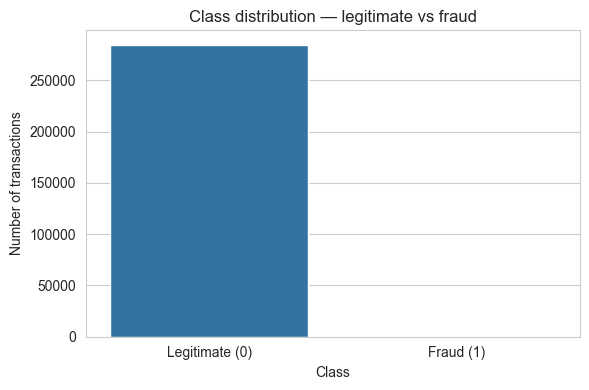

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — CLASS DISTRIBUTION
# How many fraud vs legitimate transactions are in the dataset?
# This is the most important thing to understand first.
# ─────────────────────────────────────────────────────────────

# Count each class
class_counts = df["Class"].value_counts()
fraud_count = class_counts[1]
legit_count = class_counts[0]
fraud_rate = fraud_count / len(df) * 100

print(f"Legitimate transactions : {legit_count:,}")
print(f"Fraud transactions      : {fraud_count:,}")
print(f"Fraud rate              : {fraud_rate:.3f}%")
print()
print("NOTE: This is severely imbalanced.")
print("A model that predicts 'legit' every time would be 99.8% accurate.")
print("That is why we will use F1-score and AUC-ROC, not accuracy.")

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class distribution — legitimate vs fraud")
plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"])
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()

Amount statistics — Legitimate transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Amount statistics — Fraud transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


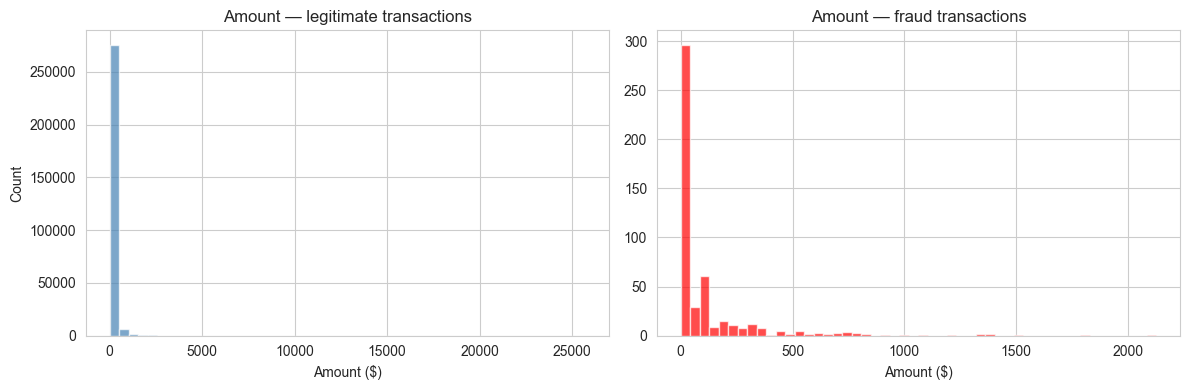

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — TRANSACTION AMOUNT ANALYSIS
# Compare how much money is involved in fraud vs legitimate.
# Fraudsters often test stolen cards with small amounts first.
# ─────────────────────────────────────────────────────────────

# Separate the two classes
legit = df[df["Class"] == 0]["Amount"]
fraud = df[df["Class"] == 1]["Amount"]

# Summary statistics side by side
print("Amount statistics — Legitimate transactions:")
print(legit.describe().round(2))
print()
print("Amount statistics — Fraud transactions:")
print(fraud.describe().round(2))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(legit, bins=50, color="steelblue", alpha=0.7)
axes[0].set_title("Amount — legitimate transactions")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Count")

axes[1].hist(fraud, bins=50, color="red", alpha=0.7)
axes[1].set_title("Amount — fraud transactions")
axes[1].set_xlabel("Amount ($)")

plt.tight_layout()
plt.show()

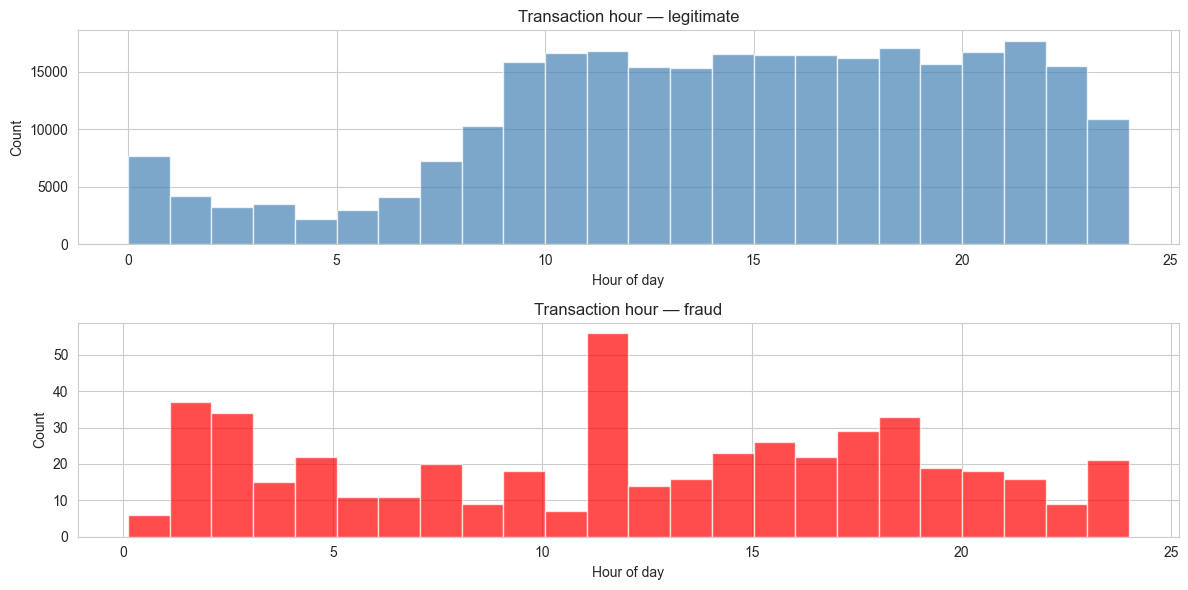

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — TIME ANALYSIS
# Time is recorded in seconds from the first transaction.
# We want to see if fraud happens at different times than legit.
# Legitimate transactions should follow a day/night rhythm.
# Fraud transactions tend to be more uniform — fraudsters don't sleep.
# ─────────────────────────────────────────────────────────────

# Convert seconds to hours for easier interpretation
df["Hour"] = (df["Time"] / 3600) % 24

# Separate by class
legit_hour = df[df["Class"] == 0]["Hour"]
fraud_hour = df[df["Class"] == 1]["Hour"]

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].hist(legit_hour, bins=24, color="steelblue", alpha=0.7)
axes[0].set_title("Transaction hour — legitimate")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Hour of day")

axes[1].hist(fraud_hour, bins=24, color="red", alpha=0.7)
axes[1].set_title("Transaction hour — fraud")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Hour of day")

plt.tight_layout()
plt.show()

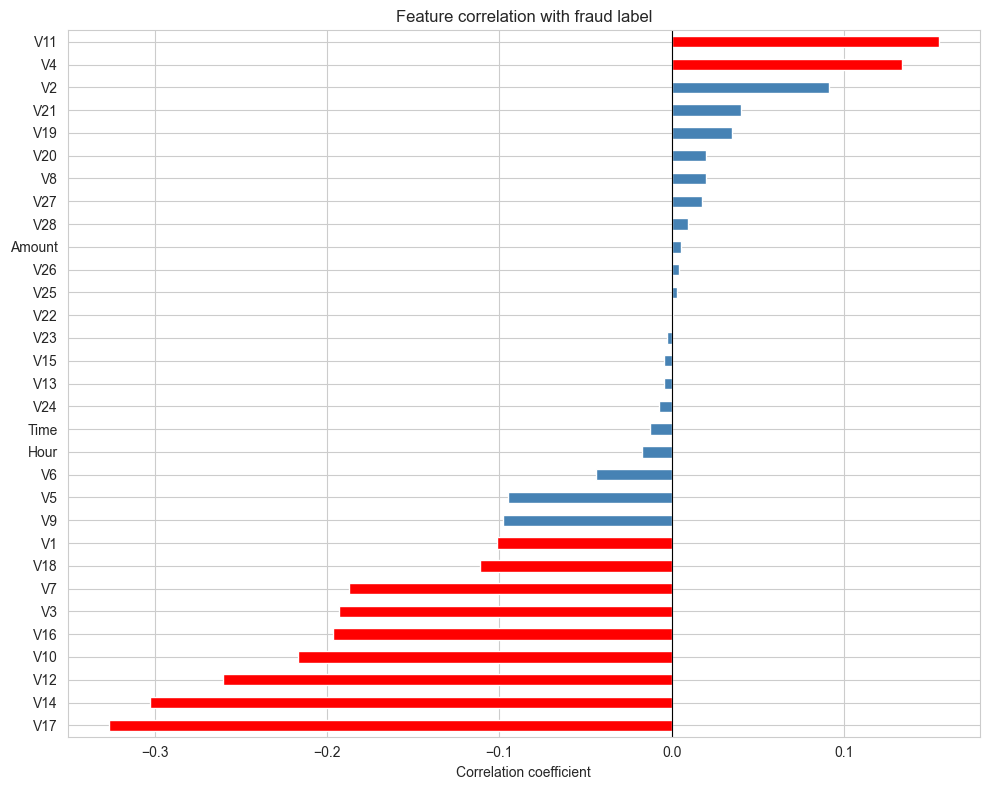

Top 5 features pointing TOWARD fraud:
V19    0.035
V21    0.040
V2     0.091
V4     0.133
V11    0.155
Name: Class, dtype: float64

Top 5 features pointing AWAY from fraud:
V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197
Name: Class, dtype: float64


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — FEATURE CORRELATION WITH FRAUD
# Which features are most strongly linked to fraud?
# This tells us which V columns our model will rely on most.
# ─────────────────────────────────────────────────────────────

# Correlation of every feature with the Class column
correlations = df.corr()["Class"].drop("Class").sort_values()

# Plot
plt.figure(figsize=(10, 8))
colors = ["red" if x < -0.1 or x > 0.1 else "steelblue" for x in correlations]
correlations.plot(kind="barh", color=colors)
plt.title("Feature correlation with fraud label")
plt.xlabel("Correlation coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# Print the top 5 positive and negative
print("Top 5 features pointing TOWARD fraud:")
print(correlations.tail(5).round(3))
print()
print("Top 5 features pointing AWAY from fraud:")
print(correlations.head(5).round(3))

## EDA Conclusions

| Finding | Implication |
|---|---|
| 492 fraud out of 284,807 (0.173%) | Severe class imbalance — cannot use accuracy as metric |
| Fraud median amount is $9.25 vs $22 legit | Fraudsters test stolen cards with small amounts first |
| Fraud spikes at hours 1–2am | Fraudsters operate when cardholders are asleep |
| V17, V14, V12, V10 strongly negative | Key features — model will rely on these most |
| V11, V4, V2 positive correlation | Secondary fraud signals |
| Zero missing values | No cleaning needed — go straight to preprocessing |

**Next step:** Notebook 2 — preprocessing, scaling, and handling class imbalance with SMOTE.